In [1]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf

In [3]:
ap_data=yf.download("AAPL",start="2019-01-01",end='2025-01-01')

[*********************100%***********************]  1 of 1 completed


In [4]:
ap_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503723,37.724587,36.627401,36.784142,148158800
2019-01-03,33.768085,34.606410,33.722963,34.193183,365248800
2019-01-04,35.209618,35.278490,34.150434,34.323797,234428400
2019-01-07,35.131233,35.344972,34.649138,35.314098,219111200
2019-01-08,35.800953,36.055064,35.271361,35.518344,164101200


In [5]:
ap_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1510 entries, 2019-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1510 non-null   float64
 1   (High, AAPL)    1510 non-null   float64
 2   (Low, AAPL)     1510 non-null   float64
 3   (Open, AAPL)    1510 non-null   float64
 4   (Volume, AAPL)  1510 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 70.8 KB


In [6]:
print(ap_data.describe())
ap_data.shape#.isnull().sum()
ap_data.columns

Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1510.000000  1510.000000  1510.000000  1510.000000  1.510000e+03
mean     134.558968   135.890927   133.064615   134.414814  9.416775e+07
std       53.947414    54.338696    53.481490    53.893810  5.232554e+07
min       33.768085    34.606410    33.722963    34.193183  2.323470e+07
25%       88.495794    89.842868    87.853745    88.439459  5.914420e+07
50%      142.816360   144.390254   141.154838   142.666133  8.152105e+07
75%      171.518440   173.034927   169.666699   171.363459  1.123920e+08
max      257.612732   258.686881   256.230300   256.787255  4.265100e+08


MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

Conclusion: Dataset Quality

Dataset is:

Complete

Clean

No missing values

Correct data types

Good size

This is production-quality data.

In [7]:
ap_data.columns = ap_data.columns.get_level_values(0)

In [8]:
ap_data.head()
ap_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [9]:
ap_data.columns.name = None

In [10]:
!pip install  matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import  matplotlib.pyplot as plt

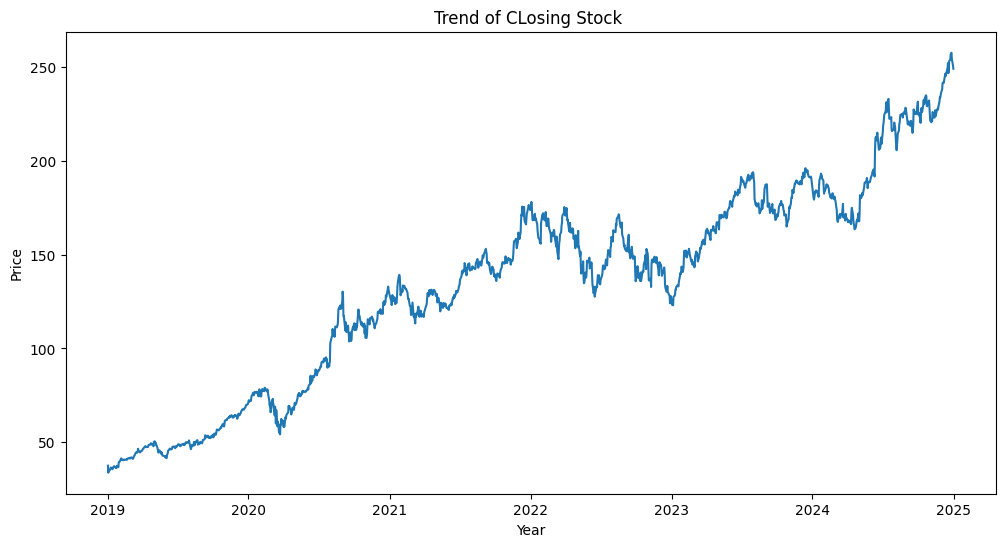

In [12]:
plt.figure(figsize=(12,6))
plt.plot(ap_data['Close'])
plt.title("Trend of CLosing Stock ")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

In [13]:
!pip install pandas
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
ap_data['Returns']=ap_data['Close'].pct_change()

In [15]:
ap_data.head(20)

,Close,High,Low,Open,Volume,Returns
Date,,,,,,
2019-01-02,37.503723,37.724587,36.627401,36.784142,148158800,NaN
2019-01-03,33.768085,34.606410,33.722963,34.193183,365248800,-0.099607
2019-01-04,35.209618,35.278490,34.150434,34.323797,234428400,0.042689
2019-01-07,35.131233,35.344972,34.649138,35.314098,219111200,-0.002226
2019-01-08,35.800953,36.055064,35.271361,35.518344,164101200,0.019063
2019-01-09,36.408913,36.698645,35.534967,35.929191,180396400,0.016982
2019-01-10,36.525284,36.565656,35.827076,36.216552,143122800,0.003196
2019-01-11,36.166687,36.501543,35.981448,36.306806,108092800,-0.009818
2019-01-14,35.622841,35.924449,35.437602,35.824705,129756800,-0.015037


In [16]:
ap_data=ap_data.dropna()

In [17]:
ap_data.head()
ap_data.isna().sum()
ap_data.isnull().sum()


Close      0
High       0
Low        0
Open       0
Volume     0
Returns    0
dtype: int64

In [18]:
ap_data['Returns'].mean()

0.001444046480984434

In [19]:
mean_return = ap_data['Returns'].mean()
risk = ap_data['Returns'].std()

print("Average Return:", mean_return)
print("Risk (Volatility):", risk)

Average Return: 0.001444046480984434
Risk (Volatility): 0.019427192641912644


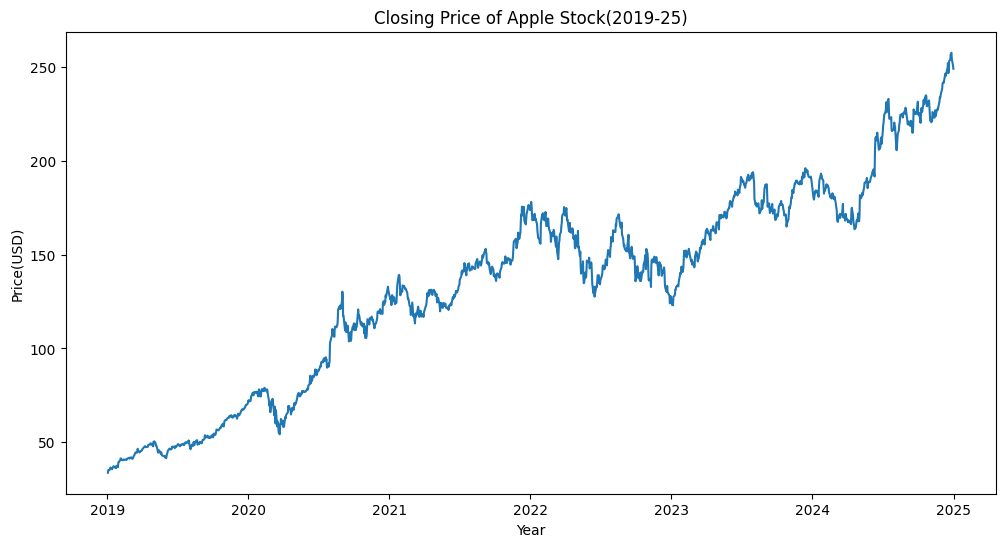

In [20]:
plt.figure(figsize=(12,6))
plt.plot(ap_data['Close'])
plt.title("Closing Price of Apple Stock(2019-25)")
plt.xlabel("Year")
plt.ylabel("Price(USD)")
plt.show()

In [21]:
ap_data.to_csv("../data/aapl_day1_cleaned.csv")

In [22]:
# import os 
# os.getcwd()

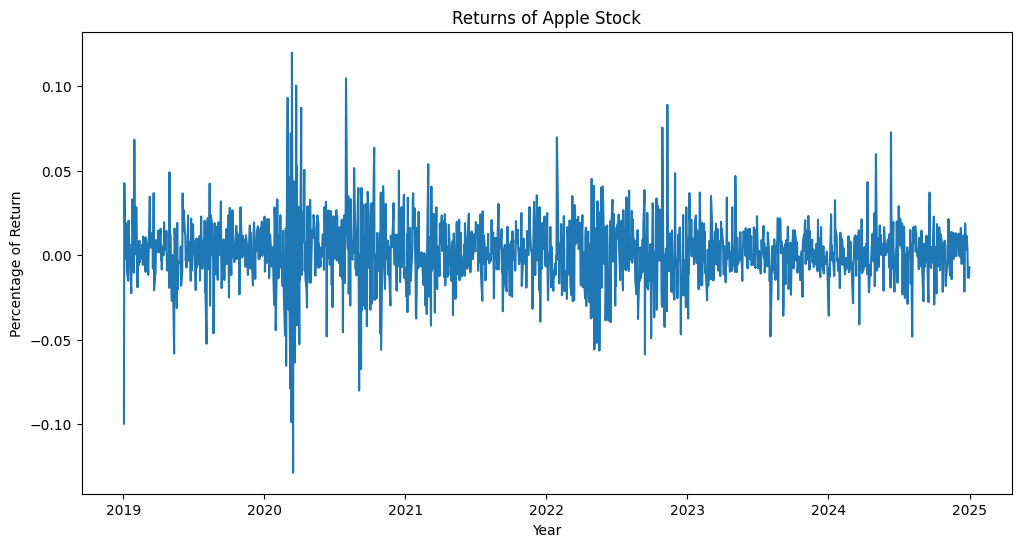

In [23]:
plt.figure(figsize=(12,6))
plt.plot(ap_data.index,ap_data['Returns'])
plt.title("Returns of Apple Stock")
plt.xlabel("Year")
plt.ylabel("Percentage of Return")
plt.show()

## Day-2 Detailed To-Do List with Time & Progress
+ Task 1 — Rolling Mean (Trend Baseline)

Purpose:

Detect normal price level.

This helps identify:

overpriced conditions (greed)

underpriced conditions (fear)


Task 2 — Rolling Standard Deviation (Volatility Engine)

Purpose:

Detect volatility spikes → panic or excitement.

This is behavioral signal.

Task 3 — Z-Score Calculation (Bias Detector Core)

Purpose:

Measure how far price is from normal.

Formula:

Z = (Price − Mean) / StdDev

This is the heart of behavioral detection.

Task 4 — Identify Fear & Greed Zones
We define:

Z > +2 → Greed Zone
Z < −2 → Fear Zone

Task 5 — Visualize Fear & Greed Signals

We mark:

Buy opportunities

Sell opportunities

Task 6 — Save Behavioral Dataset

We save enhanced dataset for optimizer engine.

##  Task 1 — Rolling Mean (Trend Baseline)

Purpose:

Detect normal price level.

This helps identify:

overpriced conditions (greed)

underpriced conditions (fear)

You already started this. We'll complete it properly.

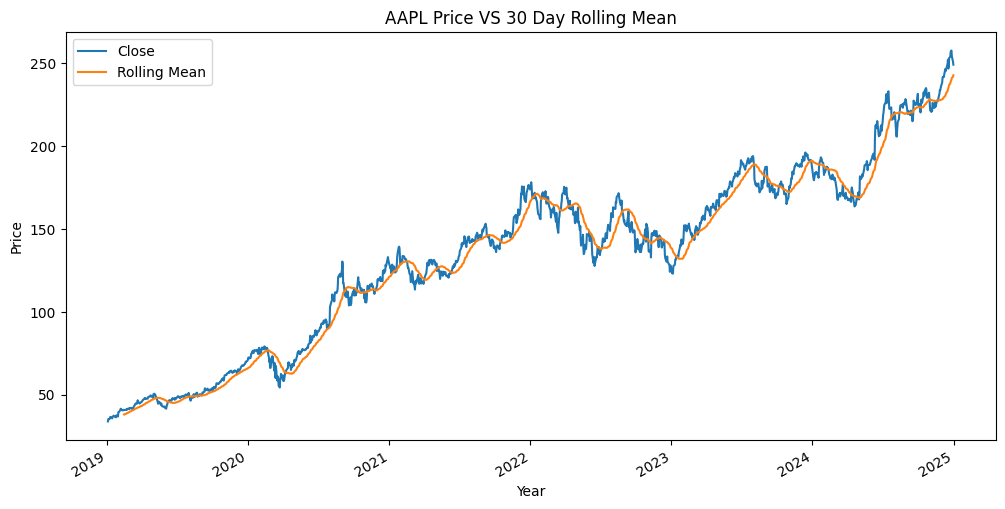

In [24]:
ap_data['Rolling Mean']=ap_data['Close'].rolling(window=30).mean()

ap_data[['Close','Rolling Mean']].plot(figsize=(12,6))
plt.title('AAPL Price VS 30 Day Rolling Mean')
plt.xlabel('Year')
plt.ylabel("Price")
plt.show()

In [25]:
# print('Rolling Mean Column')
# ap_data.shape
# ap_data[['Close','Rolling Mean']].iloc[29]
ap_data = ap_data.dropna(subset=["Rolling Mean"])

In [26]:
ap_data['Rolling Volatility']=ap_data["Returns"].rolling(window=30).std()
ap_data[['Rolling Volatility','Rolling Mean']].iloc[27:33]

,Rolling Volatility,Rolling Mean
Date,,
2019-03-26,NaN,42.516460
2019-03-27,NaN,42.656224
2019-03-28,0.012215,42.803619
2019-03-29,0.012227,42.955865
2019-04-01,0.012189,43.121387
2019-04-02,0.012340,43.304955


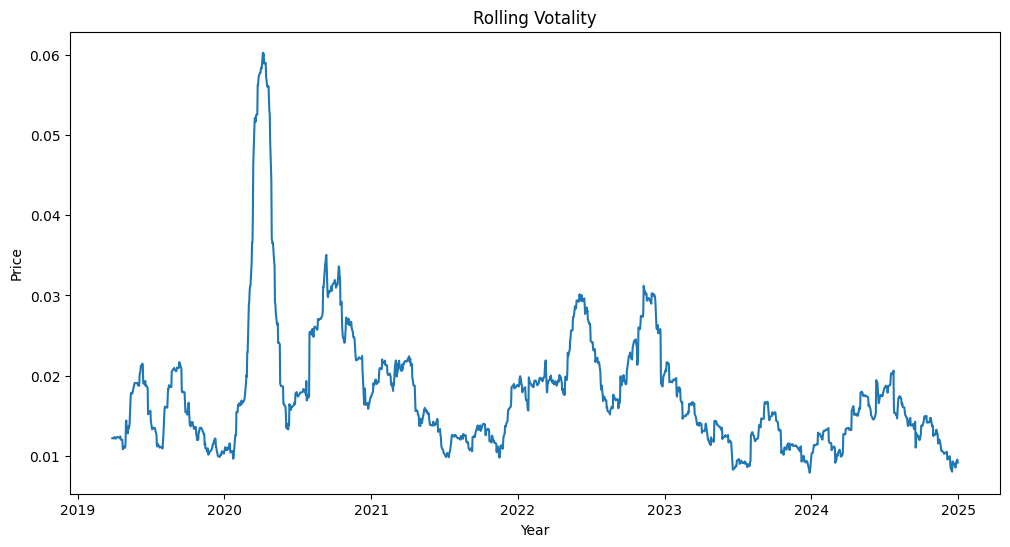

In [27]:
plt.figure(figsize=(12,6))
plt.plot(ap_data.index,ap_data['Rolling Volatility'],label='Rolling Volatility')
plt.title("Rolling Votality")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

In [28]:
ap_data.index

DatetimeIndex(['2019-02-14', '2019-02-15', '2019-02-19', '2019-02-20',
               '2019-02-21', '2019-02-22', '2019-02-25', '2019-02-26',
               '2019-02-27', '2019-02-28',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=1480, freq=None)

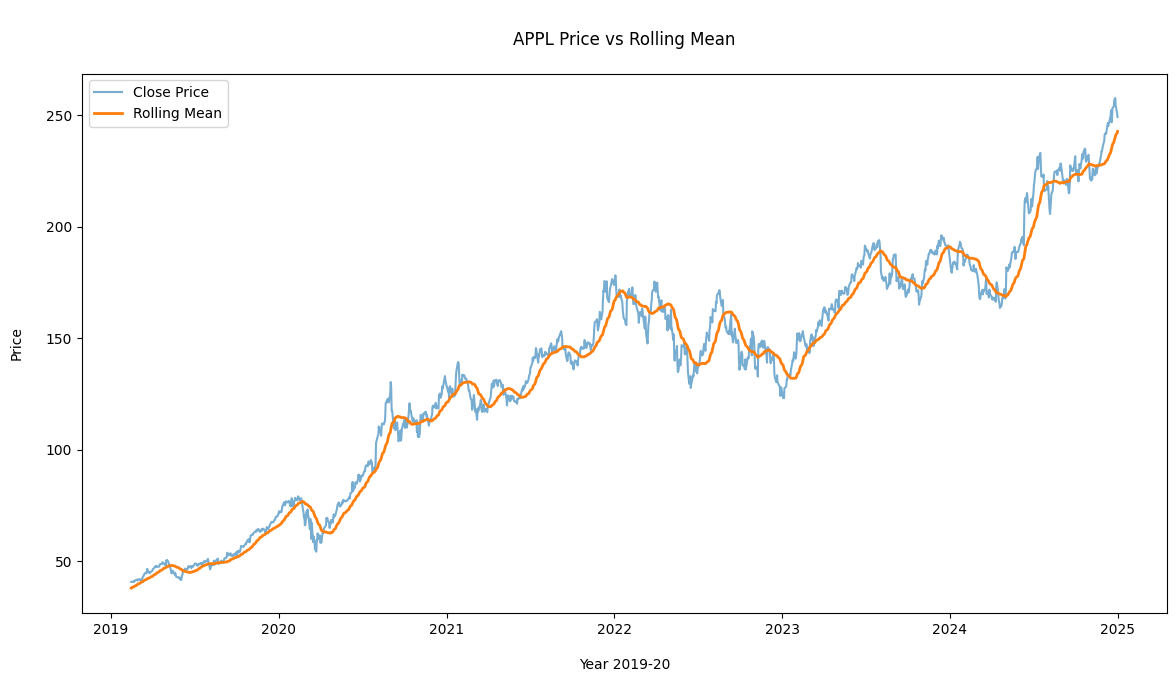

In [29]:
plt.figure(figsize=(14,7))
plt.plot(ap_data.index,ap_data['Close'],label='Close Price',alpha=0.6)
plt.plot(ap_data.index,ap_data['Rolling Mean'],label='Rolling Mean',linewidth=2)
plt.title("\nAPPL Price vs Rolling Mean\n")
plt.xlabel("\nYear 2019-20")
plt.ylabel("Price\n")
plt.legend()
plt.show()


In [30]:
correlation_R__RVOL=ap_data['Returns'].corr(ap_data['Rolling Volatility'])
print("Correlation : ",correlation_R__RVOL)

Correlation :  0.0027932525209492607


In [31]:
ap_data['Cumulative Return'] = (1+ap_data['Returns']).cumprod()
ap_data['Cumulative Return'].tail()

Date
2024-12-24    6.326826
2024-12-26    6.346918
2024-12-27    6.262871
2024-12-30    6.179804
2024-12-31    6.136188
Name: Cumulative Return, dtype: float64

C:\Users\famil\AppData\Local\Temp\ipykernel_26988\999901367.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


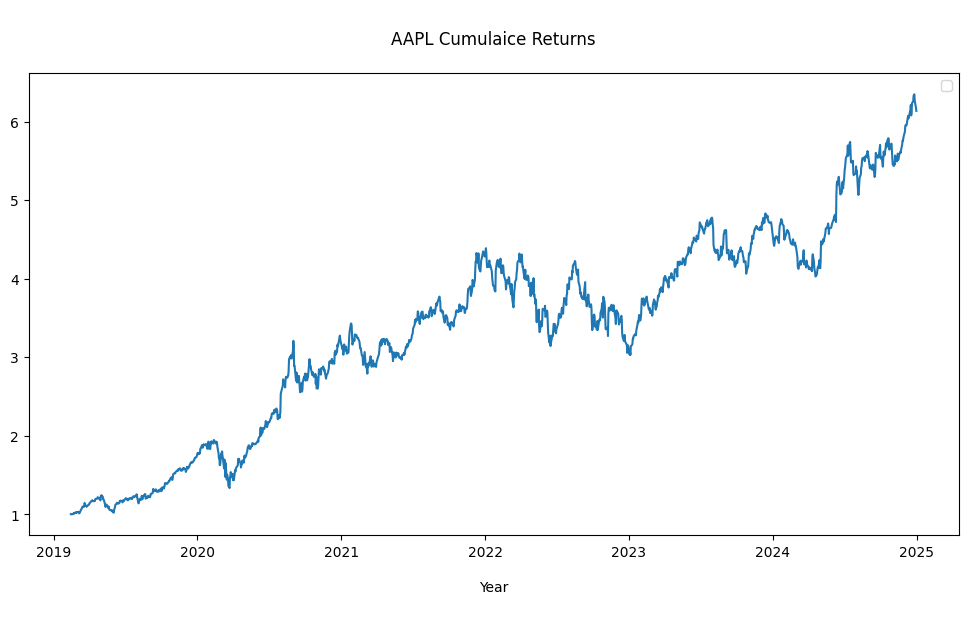

In [32]:
plt.figure(figsize=(12,6))
plt.plot(ap_data.index,ap_data['Cumulative Return'])
plt.title("\nAAPL Cumulaice Returns\n")
plt.xlabel("\nYear\n")
plt.legend()
plt.show()

In [33]:
ap_data['Fear_Greed']=ap_data['Rolling Volatility'].apply(
    lambda x: 'Fear' if x>ap_data['Rolling Volatility'].mean() else 'Greed'
)
c=0

print('\n\n',ap_data['Fear_Greed'].unique(),'\n\n')
ap_data[['Rolling Volatility','Fear_Greed']].tail(60)
ap_data['Fear_Greed'].value_counts()




 ['Greed' 'Fear'] 




Fear_Greed
Greed    899
Fear     581
Name: count, dtype: int64

In [34]:
ap_data

,Close,High,Low,Open,Volume,Returns,Rolling Mean,Rolling Volatility,Cumulative Return,Fear_Greed
Date,,,,,,,,,,
2019-02-14,40.736500,40.846210,40.397824,40.476531,87342800,0.003643,37.934863,NaN,1.003643,Greed
2019-02-15,40.645874,40.951159,40.486077,40.843833,98507200,-0.002225,38.164123,NaN,1.001410,Greed
2019-02-19,40.767506,40.889145,40.424063,40.476534,75891200,0.002992,38.349386,NaN,1.004407,Greed
2019-02-20,41.029861,41.337534,40.781819,40.829519,104457600,0.006435,38.546007,NaN,1.010871,Greed
2019-02-21,40.798512,41.110951,40.617250,40.975006,68998800,-0.005639,38.712592,NaN,1.005171,Greed
...,...,...,...,...,...,...,...,...,...,...
2024-12-24,256.797211,256.807136,253.903002,254.101927,23234700,0.011478,238.861835,0.008616,6.326826,Greed
2024-12-26,257.612732,258.686881,256.230300,256.787255,27237100,0.003176,240.015200,0.008575,6.346918,Greed
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300,-0.013242,241.025349,0.009190,6.262871,Greed


In [35]:
!pip install plotly
import plotly as go


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
fear_data=ap_data[ap_data['Fear_Greed']=='Fear']
greed_data=ap_data[ap_data['Fear_Greed']=='Greed']

In [37]:
import plotly.graph_objects as go
fig=go.Figure()

fig.add_trace(go.Scatter(
    x=ap_data.index,
    y=ap_data['Close'],
    mode='lines',
    name='Close price'
))
fig.add_trace(go.Scatter(
        x=fear_data.index,
        y=fear_data['Close'],
        mode='markers',
        name='Fear',
        marker=dict(color='red',size=4)
))
fig.add_trace(go.Scatter(
        x=greed_data.index,
        y=fear_data['Close'],
        mode='markers',
        name='Greed',
        marker=dict(color='green',size=4)
))
fig.update_layout(
  title='AAPL Price with Fear and Greed Regimes',
  xaxis_title='Date',
  yaxis_title='Price', 
 )

fig.show()

## IF Fear is high AND fundamentals strong:
    Recommendation = BUY opportunity

IF Greed is high AND price overextended:
    Recommendation = RISK warning

## Professional conclusion

Based on Fear–Greed analysis, AAPL shows sustained growth with dominant Fear sentiment during recent years, indicating cautious investor behavior rather than speculative bubble formation. This suggests stable long-term growth potential.

In [ ]:
ap_data.to_csv("../data/aapl_day2_behavioral.csv")

## Day 3

In [5]:
import pandas as pd
ap_data=pd.read_csv("../data/aapl_day1_cleaned.csv",index_col='Date',parse_dates=True)
ap_data.head()

,Close,High,Low,Open,Volume,Returns
Date,,,,,,
2019-01-03,33.768085,34.606410,33.722963,34.193183,365248800,-0.099607
2019-01-04,35.209618,35.278490,34.150434,34.323797,234428400,0.042689
2019-01-07,35.131233,35.344972,34.649138,35.314098,219111200,-0.002226
2019-01-08,35.800953,36.055064,35.271361,35.518344,164101200,0.019063
2019-01-09,36.408913,36.698645,35.534967,35.929191,180396400,0.016982


In [14]:
ap_data.shape
ap_data.index.dtype
ap_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Returns', 'Volatilty_30'], dtype='object')

In [ ]:
ap_data['Volatilty_30']=ap_data['Returns'].rolling(window=30).std()
ap_data[['Returns','Volatilty_30']].head(38)

In [ ]:
import plotly.graph_objects as go
fig=go.Figure()
fig.add_trace(go.Scatter(
    x=ap_data.index,
    y=ap_data['Close'],
    mode='lines',
    name='Price',
))

fig.add_trace(go.Scatter(
    x=ap_data.index,
    y=ap_data['Volatilty_30'],
    mode='lines',
    name='Volatility', 
    yaxis='y2',
))

fig.update_layout(
    title='Proce vs Volatility',
    
    xaxis=dict(title='Date'),
    
     yaxis=dict(title='Date',side='left'),
    
    yaxis2=dict(title='Volatility',
                 overlaying='y',
                 side='right')
    )

fig.show()


In [20]:
ap_data

,Close,High,Low,Open,Volume,Returns,Volatilty_30
Date,,,,,,,
2019-01-03,33.768085,34.606410,33.722963,34.193183,365248800,-0.099607,NaN
2019-01-04,35.209618,35.278490,34.150434,34.323797,234428400,0.042689,NaN
2019-01-07,35.131233,35.344972,34.649138,35.314098,219111200,-0.002226,NaN
2019-01-08,35.800953,36.055064,35.271361,35.518344,164101200,0.019063,NaN
2019-01-09,36.408913,36.698645,35.534967,35.929191,180396400,0.016982,NaN
...,...,...,...,...,...,...,...
2024-12-24,256.797211,256.807136,253.903002,254.101927,23234700,0.011478,0.008616
2024-12-26,257.612732,258.686881,256.230300,256.787255,27237100,0.003176,0.008575
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300,-0.013242,0.009190


In [2]:
import pandas as pd
ap_data=pd.read_csv("../data/aapl_day2_behavioral.csv",index_col='Date',parse_dates=True)
ap_data.head()

,Close,High,Low,Open,Volume,Returns,Rolling Mean,Rolling Volatility,Cumulative Return,Fear_Greed
Date,,,,,,,,,,
2019-02-14,40.736500,40.846210,40.397824,40.476531,87342800,0.003643,37.934863,NaN,1.003643,Greed
2019-02-15,40.645874,40.951159,40.486077,40.843833,98507200,-0.002225,38.164123,NaN,1.001410,Greed
2019-02-19,40.767506,40.889145,40.424063,40.476534,75891200,0.002992,38.349386,NaN,1.004407,Greed
2019-02-20,41.029861,41.337534,40.781819,40.829519,104457600,0.006435,38.546007,NaN,1.010871,Greed
2019-02-21,40.798512,41.110951,40.617250,40.975006,68998800,-0.005639,38.712592,NaN,1.005171,Greed


In [4]:
fear_avg= ap_data[ap_data['Fear_Greed']=='Fear']['Returns'].mean()
greed_avg= ap_data[ap_data['Fear_Greed']=='Greed']['Returns'].mean()
print(fear_avg,'\n',greed_avg)

0.0010752137716514294 
 0.0016288454647652255


In [5]:
fear_vol= ap_data[ap_data['Fear_Greed']=='Fear']['Returns'].std()
greed_vol= ap_data[ap_data['Fear_Greed']=='Greed']['Returns'].std()
print(fear_vol,'\n',greed_vol)

0.02574616436354984 
 0.01348166721464306


In [6]:
fr=fear_avg/fear_vol
gr=greed_avg/greed_vol
print(fr,'\t',gr)

0.04176209537346325 	 0.12081929028748473


In [7]:
ap_data.to_csv("../data/aapl_day3_behaviour.csv")

In [3]:
ap_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Returns', 'Rolling Mean',
       'Rolling Volatility', 'Cumulative Return', 'Fear_Greed'],
      dtype='object')

In [ ]:
ap_data['Risk_Adjustment_Returns']=ap_data['Returns']/ap_data['Rolling Volatility']
ap_data[['Returns','Rolling Volatility','Risk_Adjustment_Returns']].head(40)

In [5]:
print(ap_data['Risk_Adjustment_Returns'].mean(),'\n',
ap_data['Risk_Adjustment_Returns'].max(),'\n',
ap_data['Risk_Adjustment_Returns'].min())

0.09195365063212724 
 4.122462830926557 
 -3.810108447676406


In [6]:
import plotly.graph_objects as go
fig=go.Figure()
fig.add_trace(go.Scatter(
    x=ap_data.index,
    y=ap_data['Risk_Adjustment_Returns'],
    mode='lines',
    name='Risk_Adjustment_Returns'
))
fig.update_layout(
    title='Risk Adjustment Returns Over Time ',
    xaxis_title='Date',
    yaxis_title='Risk_Adjustment_Returns'
)
fig.show()

In [7]:
sharpe_Rato=ap_data['Returns'].mean()/ap_data['Returns'].std()

In [8]:
sharpe_Rato

0.07334352574971835

In [9]:
annual_sharpe=sharpe_Rato * (252 **0.5)

In [10]:
annual_sharpe

1.1642923764625013

In [11]:
ap_data.to_csv("../data/aapl_day3_features.csv")

In [ ]:
ap_data.head()

In [14]:
avg_vol=ap_data['Rolling Volatility'].mean()
ap_data['Fear_Signal'] = ap_data.apply(lambda x : "Fear" if (x['Returns']<0 and avg_vol<x['Rolling Volatility']) else 'Greed' ,axis=1)

In [ ]:
ap_data.columns

In [ ]:
ap_data[['Returns','Rolling Volatility','Fear_Signal']].head(30)

In [17]:
avg_vol=ap_data['Rolling Volatility'].mean()
#ap_data['Fear_Signal'] = ap_data.apply(lambda x : "Fear" if (x['Returns']<0 and avg_vol<x['Rolling Volatility']) else 'Greed' ,axis=1)

In [ ]:
ap_data.head()

In [ ]:
import pandas as pd
ap_data=pd.read_csv("../data/aapl_day3_features.csv",index_col='Date',parse_dates=True)
avg_vol=ap_data['Rolling Volatility'].mean()
ap_data['Fear_Signal'] = ap_data.apply(lambda x : "Fear" if (x['Returns']<0 and avg_vol<x['Rolling Volatility']) else 'Greed' ,axis=1)
ap_data.head()


In [29]:
ap_data['Investor_Bias'] = ap_data.apply(lambda x : "Fear" 
                                       if (x['Returns']<0 and avg_vol<x['Rolling Volatility']) 
                                       else ( 'Greed' if (x['Returns']>0  and avg_vol>x['Rolling Volatility'])
                                              else 'Neutral') ,axis=1)

In [ ]:
ap_data.head()

In [31]:
ap_data['Investor_Bias'].value_counts()

Investor_Bias
Neutral    722
Greed      479
Fear       279
Name: count, dtype: int64

In [ ]:
ap_data['Recommendataion']=ap_data['Investor_Bias'].map(lambda x :'Buy' if x== 'Fear' else 'Hold')
ap_data[['Recommendataion','Investor_Bias']].head(20)

In [37]:
ap_data=ap_data.drop('C',axis=1)

In [ ]:
ap_data.to_csv("../data/appl_day4_bias_recommendation.csv")

In [2]:
import pandas as pd
ap_data=pd.read_csv("../data/appl_day4_bias_recommendation.csv",index_col='Date',parse_dates=True)
ap_data.head()

,Close,High,Low,Open,Volume,Returns,Rolling Mean,Rolling Volatility,Cumulative Return,Fear_Greed,Risk_Adjustment_Returns,Fear_Signal,Investor_Bias,Recommendataion
Date,,,,,,,,,,,,,,
2019-02-14,40.736500,40.846210,40.397824,40.476531,87342800,0.003643,37.934863,NaN,1.003643,Greed,NaN,Greed,Neutral,Hold
2019-02-15,40.645874,40.951159,40.486077,40.843833,98507200,-0.002225,38.164123,NaN,1.001410,Greed,NaN,Greed,Neutral,Hold
2019-02-19,40.767506,40.889145,40.424063,40.476534,75891200,0.002992,38.349386,NaN,1.004407,Greed,NaN,Greed,Neutral,Hold
2019-02-20,41.029861,41.337534,40.781819,40.829519,104457600,0.006435,38.546007,NaN,1.010871,Greed,NaN,Greed,Neutral,Hold
2019-02-21,40.798512,41.110951,40.617250,40.975006,68998800,-0.005639,38.712592,NaN,1.005171,Greed,NaN,Greed,Neutral,Hold


In [3]:
ap_data['sharpe_Rato']=ap_data['Returns']/ap_data['Rolling Volatility']


In [6]:
ap_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Returns', 'Rolling Mean',
       'Rolling Volatility', 'Cumulative Return', 'Fear_Greed',
       'Risk_Adjustment_Returns', 'Fear_Signal', 'Investor_Bias',
       'Recommendataion', 'sharpe_Rato', 'Rolling_Sharpe'],
      dtype='object')

In [ ]:
ap_data[['Returns','Rolling Volatility','sharpe_Rato']].iloc[40:100]

In [5]:
ap_data['Rolling_Sharpe']=ap_data['sharpe_Rato'].rolling(30).mean()

In [ ]:
ap_data[['sharpe_Rato','Rolling_Sharpe']].iloc[57:255]

In [7]:
ap_data['Performance']=ap_data['Rolling_Sharpe'].apply(lambda x : 'Good' if x>0 else 'Poor')

In [8]:
ap_data['Performance'].value_counts()

Performance
Good    941
Poor    539
Name: count, dtype: int64

In [9]:
ap_data.to_csv("../data/appl_day5_behavioral_analysis.csv")

# **Professional interpretation statement (for project/report)**
- *You can write:*
+ The Rolling Sharpe Ratio classification shows that 941 periods were classified as Good and 539 as Poor. 
+ This indicates that approximately 63.6% of the market periods provided favorable risk-adjusted returns, while 36.4% reflected unfavorable conditions. 
+ This distribution suggests moderately stable market performance with significant volatility phases, suitable for further behavioral and predictive modeling.

